# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [54]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [55]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [56]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [57]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [58]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [59]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [60]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [61]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [62]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


### Conclusiones de la exploración inicial

**Tamaño de los datasets**

| Dataset | Filas | Columnas |
|---|---|---|
| `plans` | 2 | 8 |
| `users` | 4,000 | 8 |
| `usage` | 40,000 | 6 |

**Tipos de datos que requieren conversión**

- `users['reg_date']` y `users['churn_date']` son `object` y deberían ser `datetime`.
- `usage['date']` es `object` y debería ser `datetime`.

**Valores nulos detectados**

- `users['city']`: 3,531 no nulos de 4,000 → 469 ausentes (11.7%).
- `users['churn_date']`: solo 466 no nulos, pero aquí el vacío es informativo — indica que el cliente sigue activo, no que falte el dato.
- `usage['date']`: 39,950 no nulos → 50 ausentes.
- `usage['duration']` y `usage['length']`: ~18,000 y ~22,000 no nulos respectivamente. **Estos nulos son estructurales, no faltantes**: cada fila registra un solo tipo de evento, por lo que una llamada nunca tiene `length` y un mensaje nunca tiene `duration`.

**Observaciones para el siguiente paso**

- `.info()` reporta `age` como `int64` con 4,000 valores no nulos, pero eso no garantiza que sean válidos: un entero puede ser un código sentinel. Debe revisarse su rango con `.describe()`.
- `city` es `object`; hay que verificar si además de los `NaN` existen marcadores de texto como `"?"` o `"NA"`.
- `plans` no presenta nulos ni tipos incorrectos: es un catálogo de referencia listo para usarse.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [63]:
# cantidad de nulos para users
print("Cantidad de valores nulos")
print(users.isna().sum()) # Cantidad de valores nulos
print()
print("Proporción de valores nulos")
print((users.isna().mean() * 100).round (2)) # Proporción de valores nulos

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [64]:
# cantidad de nulos para usage
print("Cantidad de valores nulos")
print(usage.isna().sum())
print()
print("Proporción de valores nulos")
print((usage.isna().mean() * 100).round(2))

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### Diagnóstico de valores nulos

| Dataset | Columna | Nulos | % | Naturaleza | Acción |
|---|---|---|---|---|---|
| `users` | `city` | 469 | 11.73% | Faltante real | Investigar e imputar con `"Desconocido"` |
| `users` | `churn_date` | 3,534 | 88.35% | **Informativo** | Conservar; derivar bandera `churn` |
| `usage` | `date` | 50 | 0.13% | Faltante real | Eliminar las filas afectadas |
| `usage` | `duration` | 22,076 | 55.19% | **Estructural** | Conservar; separar por `type` |
| `usage` | `length` | 17,896 | 44.74% | **Estructural** | Conservar; separar por `type` |

**Justificación por caso**

- `city` (11.73%): cae en el rango medio; se imputa con una categoría explícita en lugar de eliminar filas, para no perder el 12% de los clientes.
- `churn_date` (88.35%): el porcentaje alto no indica un problema de calidad. Un valor vacío significa que el cliente sigue activo, por lo que la columna se conserva y se convierte en una variable booleana de churn.
- `date` (0.13%): proporción mínima; eliminar las 50 filas no afecta el análisis y evita registros sin referencia temporal.
- `duration` y `length`: los nulos son estructurales, ya que cada fila registra un solo tipo de evento. Imputarlos con cero distorsionaría los promedios de duración y longitud; el análisis debe hacerse separando llamadas y mensajes.

**Nota sobre la regla general:** el criterio de descartar columnas con más del 80% de nulos aplica cuando el vacío representa ausencia de información. En este dataset, tres de las cinco columnas con nulos los tienen por diseño, por lo que la decisión se toma según el significado de la variable y no según su porcentaje.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [65]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` - `users['user_id']`: rango 10000–13999. Es un identificador, no una magnitud; sus estadísticas descriptivas no tienen interpretación analítica. Sin valores inválidos.
- La columna `age` - `users['age']`: **valor mínimo de -999**, imposible para una edad. La desviación estándar de 123.23 años confirma la anomalía. Se trata de un sentinel presente en 55 registros (1.4%). Excluyéndolo, la edad va de 18 a 79 años con media 48.1.

In [66]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas  `usage['id']` y `usage['user_id']`: identificadores sin valores inválidos. Todos los `user_id` de `usage` existen en `users`, por lo que la integridad referencial está intacta.
- Las columnas - `usage['duration']`: rango 0–120 minutos, mediana 3.5. El máximo es plausible pero muy alejado del centro; se evaluará como outlier en el Paso 5.
- `usage['length']`: rango 0–1490 caracteres, mediana 50. Mismo caso que el anterior.

In [67]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].value_counts(dropna=False))
    print()


--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna  - `users['city']`: presenta **dos tipos de faltante**: 469 valores `NaN` y 96 registros con el texto `"?"`, que suman 565 casos (14.1%). Adicionalmente, la nomenclatura es inconsistente: las ciudades colombianas aparecen con nombre completo (Bogotá, Medellín, Cali) y las mexicanas como siglas (CDMX, GDL, MTY).

- La columna  - `users['plan']`: solo dos categorías válidas, Basico (2,595) y Premium (1,405), coherentes con el catálogo de `plans`. Sin problemas.

In [68]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna - `usage['type']`: solo dos categorías válidas, text (22,092) y call (17,908). Sin problemas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Acciones recomendadas**

| Columna | Hallazgo | Acción |
|---|---|---|
| `users['age']` | Sentinel `-999` en 55 filas | Reemplazar por `NaN` para que no contamine las estadísticas |
| `users['city']` | Sentinel `"?"` en 96 filas | Unificar con los `NaN` existentes y luego imputar como `"Desconocido"` |
| `users['city']` | Nomenclatura inconsistente | Estandarizar siglas a nombre completo para facilitar el análisis por ciudad |
| `usage['duration']`, `usage['length']` | Valores extremos | No corregir aquí; evaluar formalmente con el método IQR en el Paso 5 |

**Nota metodológica:** el sentinel de `age` no aparece con `.isna()` ni con `.info()`, ya que `-999` es un entero técnicamente válido. Solo se detecta revisando el rango de valores, lo que confirma que un dataset sin nulos no equivale a un dataset sin errores.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [69]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [70]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [71]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`:
**`users['reg_date']`**

| Año | Registros |
|---|---|
| 2022 | 1,314 |
| 2023 | 1,316 |
| 2024 | 1,330 |
| 2026 | 40 |

La conversión con `errors='coerce'` no generó ningún `NaT`, por lo que todos los valores tenían formato válido. Sin embargo, **40 registros aparecen en 2026**, año posterior al cierre de los datos (2024). Todos comparten la misma fecha exacta (`2026-05-10`), lo que apunta a un valor por defecto mal asignado durante la carga y no a 40 errores independientes de captura.


In [72]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`:
**`usage['date']`**

| Año | Registros |
|---|---|
| 2024 | 39,950 |
| NaT | 50 |

Toda la actividad se concentra en 2024, específicamente entre enero y junio. Los 50 `NaT` corresponden a los nulos ya identificados en la revisión de valores faltantes, no a fallas de conversión.



Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Acciones recomendadas**

| Caso | Acción | Justificación |
|---|---|---|
| `reg_date` en 2026 (40 filas) | Marcar como `NaT` | Son fechas imposibles; conservarlas distorsionaría cualquier cálculo de antigüedad del cliente. Se marcan en lugar de eliminar la fila, porque el resto de los datos de esos usuarios es válido |
| `usage['date']` con `NaT` (50 filas) | Eliminar las filas | Representan el 0.13% del dataset y un evento sin fecha no puede ubicarse en ninguna ventana de análisis |

**Nota sobre el alcance temporal:** los clientes se registran entre 2022 y 2024, pero la actividad registrada cubre únicamente el primer semestre de 2024. Todo análisis de consumo se refiere a esa ventana de seis meses, no a la vida completa del cliente. Esta distinción es relevante al interpretar cualquier métrica de uso por antigüedad.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [73]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [74]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [75]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date']>'2024-12-31','reg_date'] = pd.NaT


# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

In [76]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 250.1+ KB


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [77]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [78]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

### Diagnóstico de nulos en `duration` y `length`

**Paso 1: ¿Los valores faltantes dependen de algún grupo? (MAR)**

Proporción de nulos por tipo de evento:

| Columna | `type = call` | `type = text` |
|---|---|---|
| `duration` | 0.000000 | 0.999276 |
| `length` | 0.999330 | 0.000000 |

La dependencia respecto a `type` es total: ninguna llamada carece de `duration` y ningún mensaje carece de `length`. La ausencia queda completamente explicada por una variable observada, por lo que **se confirma el patrón MAR**.

A diferencia del caso everpeak visto en la lección — donde las proporciones por grupo eran similares y llevaban a concluir MCAR — aquí el contraste es de 0% contra 99.9%. La dependencia es determinista, no probabilística, por lo que no es necesario aplicar el Paso 2 (bandera de faltantes y comparación de comportamiento) para descartar MNAR.

**Decisión: dejar los valores como nulos**

Estos campos no representan información perdida, sino campos que **no aplican** al tipo de evento: una llamada no tiene longitud en caracteres y un mensaje no tiene duración en minutos.

- **No imputar con cero:** crearía llamadas de duración cero y mensajes de longitud cero que nunca existieron, sesgando a la baja todos los promedios.
- **No imputar con la mediana:** inventaría actividad en aproximadamente 20,000 registros por columna.
- **No eliminar filas:** cada registro nulo en una columna tiene información válida en la otra; eliminarlos descartaría la mitad de la actividad.
- **Dejarlos como nulos** permite que `.mean()`, `.median()` y `.describe()` los excluyan automáticamente, que es el comportamiento correcto.

**Implicación metodológica:** todo cálculo sobre duración o longitud debe realizarse separando el dataset por tipo de evento (`usage[usage['type'] == 'call']` y `usage[usage['type'] == 'text']`), nunca sobre la tabla completa.

**Hallazgo adicional:** las proporciones no son exactamente 0.0 y 1.0. El valor de 0.999276 en `text` corresponde a 16 mensajes que sí registran `duration`, y el 0.999330 en `call` a 12 llamadas que registran `length`. Estos 28 registros contradicen la estructura del dataset y constituyen errores de captura, no ausencias clasificables como MAR.

In [79]:
# Inspeccionar los 28 registros inconsistentes
inconsistentes = usage[
    ((usage['type'] == 'text') & usage['duration'].notna()) |
    ((usage['type'] == 'call') & usage['length'].notna())
]
print("Registros inconsistentes:", len(inconsistentes))
inconsistentes[['id', 'user_id', 'type', 'duration', 'length']].head(10)

Registros inconsistentes: 28


,id,user_id,type,duration,length
1414,1415,10399,text,120.00,65.0
1824,1825,12936,text,120.00,40.0
1932,1933,10189,text,120.00,69.0
2070,2071,13139,call,1.68,1490.0
2972,2973,10085,text,120.00,68.0
5272,5273,11750,call,3.78,1490.0
10614,10615,13855,call,0.53,1490.0
11456,11457,13325,text,120.00,23.0
12692,12693,12263,call,1.80,1490.0
16702,16703,10484,text,120.00,48.0


In [80]:
# Anular los campos que no corresponden al tipo de evento
usage.loc[usage['type'] == 'text', 'duration'] = np.nan
usage.loc[usage['type'] == 'call', 'length'] = np.nan

# Verificar cambios
print(usage['duration'].isna().groupby(usage['type']).mean())
print()
print(usage['length'].isna().groupby(usage['type']).mean())

type
call    False
text     True
Name: duration, dtype: bool

type
call     True
text    False
Name: length, dtype: bool


**Corrección aplicada a 28 registros inconsistentes**

Las proporciones no eran exactamente 0.0 y 1.0. El valor de 0.999276 en `text` corresponde a 16 mensajes que registraban `duration`, y el 0.999330 en `call` a 12 llamadas que registraban `length`.

La inspección de esas filas muestra que **no** tienen el `type` mal asignado: conservan su campo correcto y además traen un campo que no corresponde a su tipo de evento. Los 16 mensajes registran `duration = 120.0` y las 12 llamadas `length = 1490.0`, en ambos casos el mismo valor en todos los registros afectados, lo que apunta a un valor inyectado por defecto y no a errores de captura independientes.

Se corrigió anulando únicamente el campo que no aplica, preservando la información válida de cada evento. No se eliminaron filas, ya que cada una documenta un evento real, ni se modificó `type`, pues no existe evidencia de que esté mal asignado.

Tras la corrección, las proporciones son exactamente 0.0 para el tipo que sí registra el campo y 1.0 para el que no, confirmando que el dataset ya respeta su estructura.

**Implicación metodológica:** todo cálculo sobre duración o longitud debe realizarse separando el dataset por tipo de evento (`usage[usage['type'] == 'call']` y `usage[usage['type'] == 'text']`), nunca sobre la tabla completa.

**Nota para el análisis de outliers:** los valores 120.0 y 1490.0 aparecen 30 veces cada uno en el dataset completo, incluyendo registros válidos. Su repetición exacta sugiere que son topes artificiales y no observaciones reales, lo cual debe considerarse al evaluar valores extremos en el Paso 5.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [81]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [82]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [83]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [84]:
# Comprobacion usuarios sin ctividad
print("Filas:", len(user_profile))
print("Usuarios sin actividad:", user_profile['cant_mensajes'].isna().sum())

Filas: 4000
Usuarios sin actividad: 1


### Perfil de uso por usuario

Se construyó una tabla agregada que resume la actividad de los seis meses en una sola fila por cliente. El dataset `usage` registra eventos individuales — 40,000 llamadas y mensajes sueltos — y esa granularidad no permite comparar clientes entre sí. La agregación por `user_id` convierte esa bitácora de eventos en un **perfil de comportamiento**.

**Métricas construidas**

| Columna | Cálculo | Qué representa |
|---|---|---|
| `cant_mensajes` | Suma de `is_text` | Total de mensajes enviados en el período |
| `cant_llamadas` | Suma de `is_call` | Total de llamadas realizadas en el período |
| `cant_minutos_llamada` | Suma de `duration` | Minutos totales consumidos en llamadas |

Las columnas auxiliares `is_text` e `is_call` convierten la variable categórica `type` en indicadores binarios (1/0), lo que permite obtener conteos por usuario mediante una suma.

`cant_minutos_llamada` suma únicamente duraciones de llamadas reales, ya que las duraciones espurias detectadas en registros de tipo `text` fueron anuladas en el paso anterior. Sin esa corrección, el total de minutos de 16 usuarios habría quedado inflado en 120 minutos cada uno.

**Integración con el perfil demográfico**

La tabla agregada se combinó con `users` mediante `user_id` usando un **left join**, lo que conserva las 4,000 filas del dataset de clientes.

La elección del tipo de unión no es trivial: existe un usuario sin actividad registrada en el período. Con un `inner join` ese cliente desaparecería del análisis, cuando en realidad representa exactamente el perfil que interesa al equipo de retención — un cliente activo en el sistema que no generó consumo alguno. Con `left join` se conserva, con valores nulos en las tres métricas de uso.

**Resultado:** `user_profile` integra en una sola tabla los atributos demográficos (edad, ciudad, plan, antigüedad, churn) y el comportamiento real de consumo, quedando lista para el análisis de distribuciones, detección de outliers y segmentación de los pasos siguientes.

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [85]:
# Resumen estadístico de las columnas numéricas
columnas_num = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_num].describe().round(2)

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,3999.00,3999.00,3999.00
mean,48.14,5.52,4.48,22.84
std,17.69,2.36,2.14,16.59
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.10
50%,48.00,5.00,4.00,19.74
75%,63.00,7.00,6.00,31.18
max,79.00,17.00,15.00,155.69


In [86]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

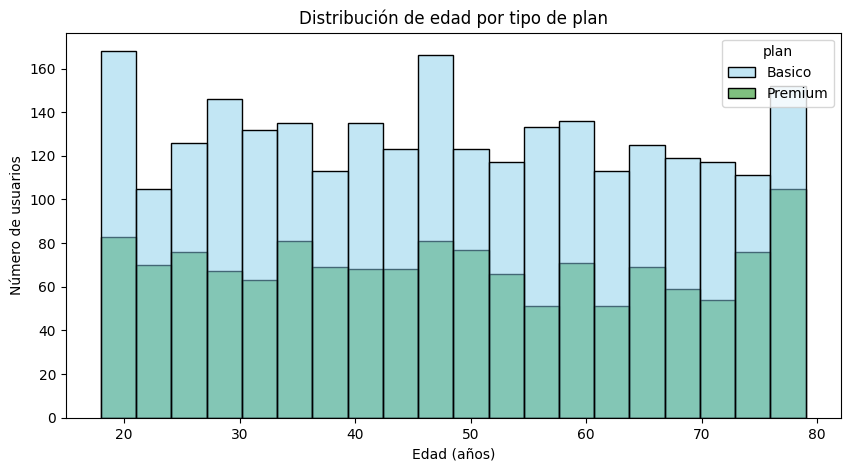

In [87]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad (años)')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- **Distribución simétrica y prácticamente uniforme.** La edad se reparte de forma pareja entre los 18 y los 79 años, sin una concentración marcada en ningún rango. Media (48.14) y mediana (48.0) coinciden, con una asimetría de 0.05.
- **No existe ningún patrón relacionado a la edad entre planes.** La edad media es de 48.04 años en Básico y 48.31 en Premium. Las dos distribuciones tienen la misma forma y la proporción entre ellas se mantiene constante en todos los rangos de edad.
- **Implicación comercial:** la contratación de Premium no está asociada a la edad del cliente. Una campaña de migración a Premium dirigida por grupo de edades no tendría fundamento en estos datos.

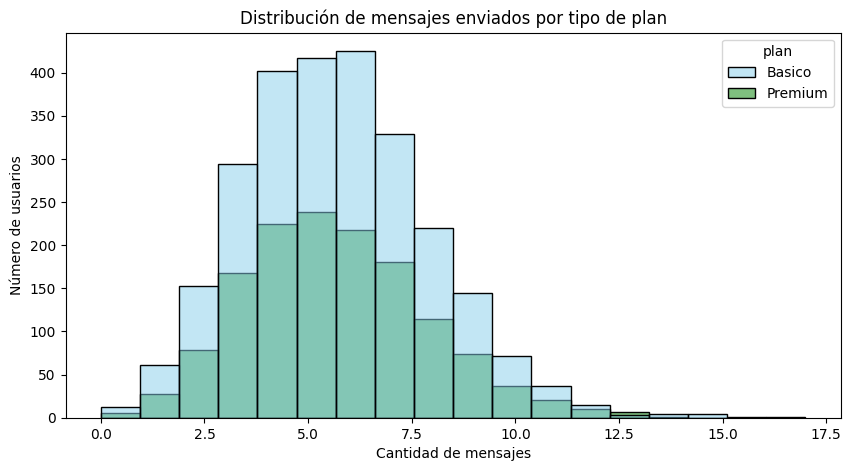

In [88]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=18)
plt.title('Distribución de mensajes enviados por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Número de usuarios')
plt.show()


💡Insights: 
- **Distribución ligeramente sesgada a la derecha** (asimetría 0.46), con forma cercana a la normal. La mayoría de los usuarios envía entre 4 y 7 mensajes en el semestre, con una cola corta que se extiende hasta 17.
- **No hay diferencia entre planes:** la mediana es de 5 mensajes tanto en Básico como en Premium, y la media es prácticamente idéntica (5.53 contra 5.52).
- **Consumo muy por debajo de lo incluido.** El plan Básico incluye 100 mensajes y el Premium 500; el consumo mediano es de 5. Ningún usuario del dataset se acerca siquiera al límite del plan más económico.

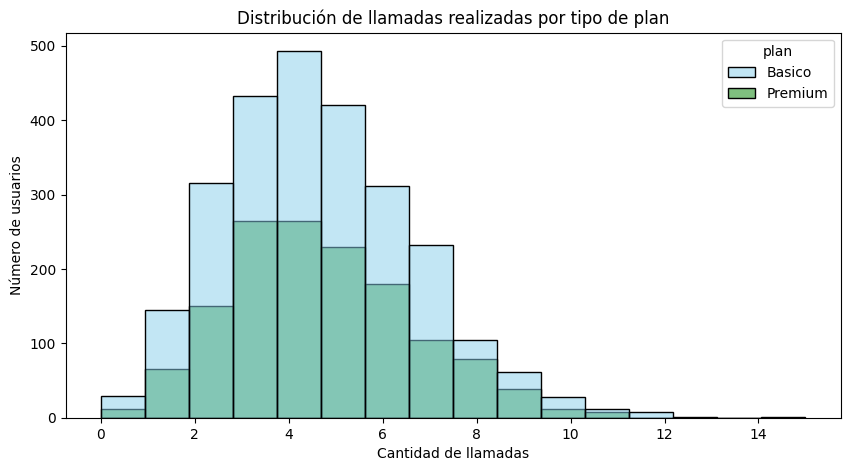

In [89]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=16)
plt.title('Distribución de llamadas realizadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- **Distribución ligeramente sesgada a la derecha** (asimetría 0.51), con el grueso de los usuarios entre 3 y 6 llamadas y una cola que llega a 15.
- **Nuevamente sin diferencia entre planes:** mediana de 4 llamadas en ambos, con medias de 4.46 en Básico y 4.52 en Premium.
- El comportamiento replica al de los mensajes: el conteo de eventos produce distribuciones compactas y centradas, sin valores extremos relevantes.

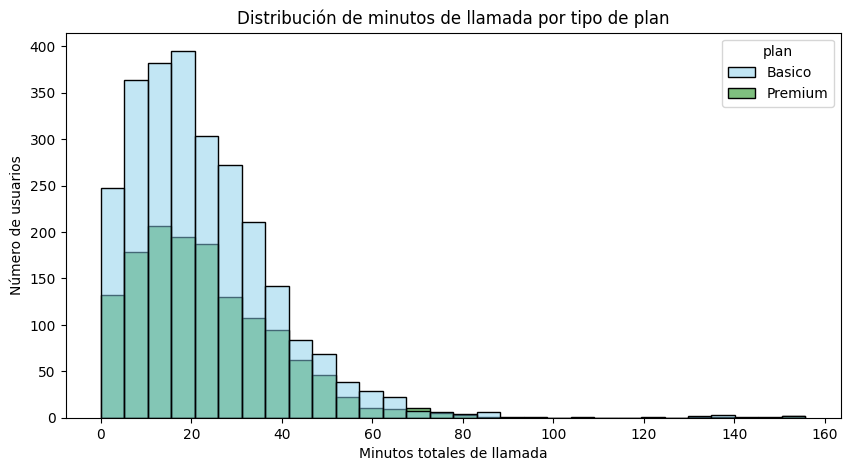

In [90]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=30)
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- **La única variable con sesgo pronunciado a la derecha** (asimetría 1.99). La media (22.84 min) supera claramente a la mediana (19.74 min) y existe una cola larga que se extiende hasta 155.69 minutos.
- **Tampoco se observan diferencias entre planes:** mediana de 19.52 minutos en Básico y 20.30 en Premium.
- **Por qué esta variable sí se sesga:** las otras métricas cuentan eventos discretos, mientras que esta acumula duraciones. Sumar variables continuas concentra la variabilidad en unos pocos usuarios de consumo intensivo, produciendo la cola derecha.
- Es la variable donde cabe esperar outliers formales al aplicar el método IQR en el bloque siguiente.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

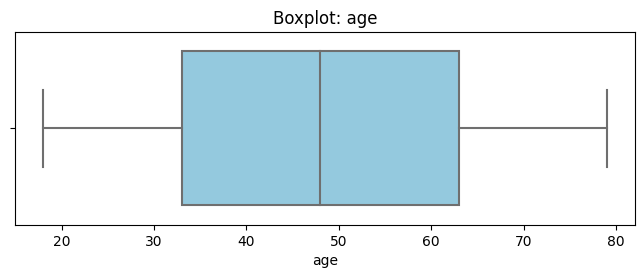

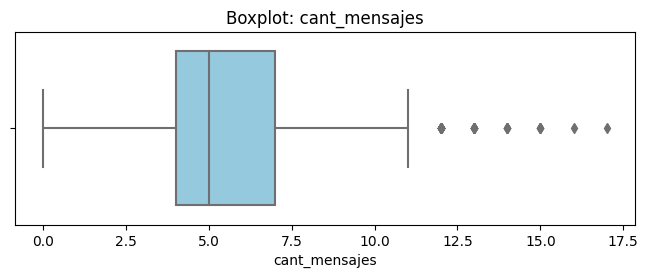

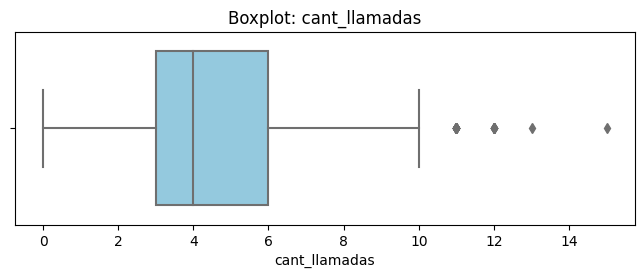

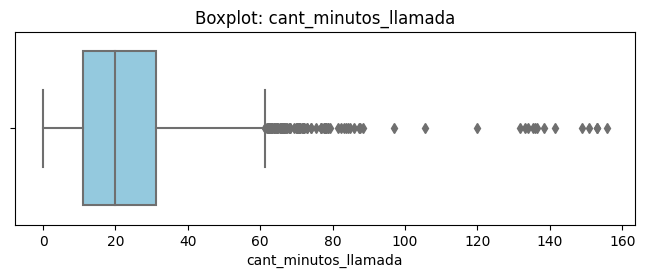

In [91]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡Insights: 
- **age:** No presenta outliers según el método IQR. Las edades observadas van de 18 a 79 años y están dentro de los límites calculados (−12 a 108 años).
- **cant_mensajes:** Presenta outliers superiores: 46 usuarios (1.15%) superan el límite de 11.5 mensajes. El máximo observado es de 17 mensajes.
- **cant_llamadas:** Presenta outliers superiores: 30 usuarios (0.75%) superan el límite de 10.5 llamadas. El máximo observado es de 15 llamadas.
- **cant_minutos_llamada:** Presenta outliers superiores: 96 usuarios (2.40%) superan el límite aproximado de 61.32 minutos. El máximo observado es de 155.69 minutos. Es la variable de uso con mayor proporción de valores atípicos.

In [92]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    n_outliers = (user_profile[col] > limite_superior).sum()
    
    print(f"--- {col} ---")
    print(f"Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Outliers por encima: {n_outliers} ({n_outliers / user_profile[col].count() * 100:.2f}%)")
    print()



--- cant_mensajes ---
Q1: 4.00 | Q3: 7.00 | IQR: 3.00
Límite superior: 11.50
Outliers por encima: 46 (1.15%)

--- cant_llamadas ---
Q1: 3.00 | Q3: 6.00 | IQR: 3.00
Límite superior: 10.50
Outliers por encima: 30 (0.75%)

--- cant_minutos_llamada ---
Q1: 11.09 | Q3: 31.18 | IQR: 20.09
Límite superior: 61.32
Outliers por encima: 96 (2.40%)



In [93]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes:** Mantener todos los outliers. El máximo de 17 mensajes es plausible y no hay evidencia suficiente para considerarlo un error de captura. Estos registros permiten identificar clientes con mayor consumo relativo.

- **cant_llamadas:** Mantener todos los outliers. El máximo de 15 llamadas es posible durante el período analizado. Eliminarlos excluiría clientes relevantes para la segmentación por actividad.

- **cant_minutos_llamada:** Mantener todos los outliers en esta etapa. El máximo acumulado de 155.69 minutos es plausible. Conviene revisar las llamadas individuales de 120 minutos, pero superar el límite del IQR no demuestra que sean errores.

**Sobre qué hacer con ellos:** Se mantienen los outliers de las tres variables porque representan posibles clientes de alto consumo relativo, un grupo que a ConnectaTel le interesa identificar. Eliminarlos podría borrar información comercial útil.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [94]:
# Completar los conteos del usuario sin actividad registrada
columnas_conteo = ['cant_llamadas', 'cant_mensajes']
user_profile[columnas_conteo] = user_profile[columnas_conteo].fillna(0)

# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),

    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10)
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    ['Bajo uso', 'Uso medio'],
    default='Alto uso'
)

In [95]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [96]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(
    [
        user_profile['age'] < 30,
        user_profile['age'] < 60
    ],
    ['Joven', 'Adulto'],
    default='Adulto Mayor'
)

In [97]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

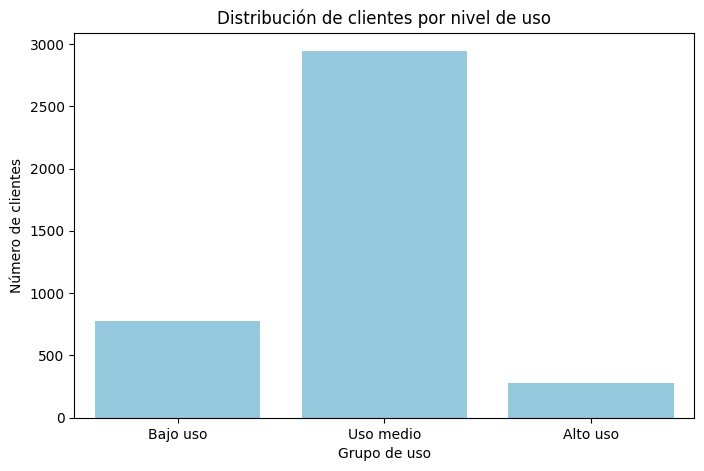

In [98]:
# Visualización de los segmentos por uso                 

plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    color='skyblue'
)

plt.title('Distribución de clientes por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de clientes')
plt.show()

💡 **Insights:**

| Grupo de uso | Clientes | % |
|---|---|---|
| Bajo uso | 779 | 19.5% |
| Uso medio | 2,943 | 73.6% |
| Alto uso | 278 | 7.0% |

- **La cartera está fuertemente concentrada en el segmento medio.** Casi tres de cada cuatro clientes (73.6%) caen en "Uso medio", lo que refleja la baja dispersión observada en las distribuciones de llamadas y mensajes.
- **El segmento de alto uso es marginal: apenas 7% de la base** (278 clientes). Es el grupo más pequeño, pero el de mayor valor potencial.
- **Uno de cada cinco clientes (19.5%) está en bajo uso**, con menos de 5 llamadas y 5 mensajes en seis meses. Es un volumen relevante de clientes prácticamente inactivos y, por tanto, de riesgo de fuga.
- **Los cortes de la segmentación son estrictos respecto al consumo real.** Los umbrales de 5 y 10 eventos están muy por debajo de lo que incluye incluso el plan Básico (100 minutos y 100 mensajes), lo que confirma que la base de clientes subutiliza ampliamente los planes contratados.

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    color='lightgreen'
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de clientes')
plt.show()

💡 **Insights:**

| Grupo de edad | Clientes | % |
|---|---|---|
| Joven (< 30) | 760 | 19.0% |
| Adulto (30–59) | 2,018 | 50.4% |
| Adulto Mayor (60+) | 1,222 | 30.6% |

- **El grupo Adulto concentra la mitad de la cartera (50.4%)**, aunque esto responde principalmente a la amplitud del rango: abarca 30 años, contra los 12 del grupo Joven.
- **Normalizado por año de edad**, la densidad es prácticamente idéntica entre los tres grupos (≈63 clientes por año en Joven, ≈67 en Adulto, ≈61 en Adulto Mayor), consistente con la distribución uniforme detectada en el histograma de edad.
- **La composición de edades de la base es equilibrada**, sin un segmento generacional dominante, lo que descarta estrategias comerciales orientadas a un único grupo de edad.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

## Análisis ejecutivo

### ⚠️ Problemas detectados en los datos

- **`age` con sentinel `-999`** en 55 registros (1.4% de 4,000). No aparecía como nulo porque es un entero técnicamente válido; solo se detectó al revisar el rango. Distorsionaba gravemente las estadísticas: la desviación estándar era de 123 años. Imputado con la mediana (48), calculada excluyendo el sentinel para no contaminar el reemplazo.
- **`city` con dos tipos de faltante**: 469 nulos más 96 registros con el texto `"?"`, en total 565 casos (14.1%). Adicionalmente, la nomenclatura es inconsistente entre países — ciudades colombianas con nombre completo y mexicanas como siglas.
- **`churn_date` completamente corrupta**: los 466 valores existentes venían en notación científica con coma decimal (`1,71832E+18`), resultado de timestamps Unix procesados en hoja de cálculo.
- **40 fechas de registro en 2026** (1.0%), posteriores al cierre de los datos. Todas con la misma fecha exacta, lo que indica un valor por defecto mal asignado y no errores independientes de captura.
- **50 eventos sin fecha** en `usage` (0.13%).
- **28 registros con campos cruzados** (0.07%): 16 mensajes con duración y 12 llamadas con longitud en caracteres. En todos los casos el valor espurio era idéntico (120.0 y 1490.0 respectivamente), señal de inyección por defecto. Se corrigieron anulando el campo que no aplica, sin eliminar filas ni modificar el tipo de evento.
- **Nulos estructurales correctamente preservados**: ~55% en `duration` y ~45% en `length` no son datos perdidos sino campos que no aplican al tipo de evento. Se verificó su condición MAR mediante dependencia respecto a `type` (0% contra 99.9%) y se conservaron como nulos. Imputarlos con cero habría sesgado a la baja todos los promedios de consumo.

### 🔍 Segmentos por Edad

| Grupo | Clientes | % |
|---|---|---|
| Joven (< 30) | 760 | 19.0% |
| Adulto (30–59) | 2,018 | 50.4% |
| Adulto Mayor (60+) | 1,222 | 30.6% |

- La distribución de edad es **prácticamente uniforme** entre los 18 y 79 años. La aparente dominancia del grupo Adulto responde a la amplitud de su rango (30 años frente a 12 del grupo Joven); normalizada por año de edad, la densidad es equivalente en los tres grupos.
- **La edad no predice el nivel de consumo.** La proporción de clientes de alto uso se mantiene entre 6.1% y 7.6% en los tres grupos de edades. Cualquier campaña segmentada por edad carecería de fundamento en estos datos.

### 📊 Segmentos por Nivel de Uso

| Grupo | Clientes | % | Minutos (mediana) |
|---|---|---|---|
| Bajo uso | 779 | 19.5% | 12.75 |
| Uso medio | 2,943 | 73.6% | 21.48 |
| Alto uso | 278 | 7.0% | 25.83 |

- **Tres de cada cuatro clientes se concentran en el segmento medio**, consecuencia de la baja dispersión del consumo: la mediana es de 5 mensajes y 4 llamadas en seis meses.
- **El segmento de alto uso representa apenas 7% de la base**, pero es el único con potencial de crecimiento en ingreso por cliente.
- **Uno de cada cinco clientes está prácticamente inactivo** (menos de 5 llamadas y 5 mensajes en el semestre), lo que representa riesgo de cancelación.
- **La composición de planes es idéntica en los tres niveles de uso** (~65% Básico / ~35% Premium en cada uno), la misma proporción que la base completa.

### 🔁 Esto sugiere que…

**El plan contratado no guarda ninguna relación con el consumo real.** Los clientes Premium pagan 25 USD por 600 minutos y 500 mensajes, mientras consumen una mediana de 20 minutos y 5 mensajes — exactamente lo mismo que los clientes Básico, que pagan 12 USD. La segmentación comercial actual no está alineada con el comportamiento observado.

Dos consecuencias directas:

- **185 clientes de alto uso están en plan Básico** (66.5% de ese segmento). Son los usuarios que más consumen pagando la tarifa más baja.
- **266 clientes de bajo uso están en plan Premium.** Pagan la tarifa alta por capacidad que no utilizan, escenario clásico de cancelación por percepción de sobrepago.

Adicionalmente, **toda la cartera subutiliza masivamente su plan**. El consumo mediano representa menos del 20% de los minutos y el 5% de los mensajes incluidos en el plan más económico. La oferta actual está dimensionada muy por encima de la demanda real.

### 🎯 Patrones de uso extremo (outliers)

- `cant_minutos_llamada` es la única variable con sesgo pronunciado (asimetría 1.99). El método IQR identifica 96 clientes (2.4%) por encima del límite de 61.32 minutos, con un máximo de 155.69 — casi 8 veces la mediana.
- `cant_mensajes` y `cant_llamadas` presentan 46 y 30 outliers respectivamente (1.15% y 0.75%), pero sus máximos están apenas 1.5 veces por encima del límite. Corresponden al extremo natural de distribuciones sesgadas, no a anomalías.
- **Se conservaron todos los outliers.** No son errores de captura sino clientes reales de consumo intensivo, y constituyen precisamente el segmento de mayor interés comercial. Eliminarlos habría borrado del análisis a los usuarios con mayor potencial de ingreso.
- **Hallazgo de calidad:** los valores 120.0 (minutos) y 1490.0 (caracteres) se repiten exactamente 30 veces cada uno en el dataset original, incluyendo registros válidos. Su repetición sugiere topes artificiales del sistema de captura y no observaciones reales, lo que debe verificarse con el equipo de datos antes de usarlos como referencia de consumo máximo.

### 💡 Recomendaciones

**1. Campaña de migración dirigida a 185 clientes.** Ofrecer plan Premium a los usuarios de alto uso actualmente en Básico. Es la acción más accionable del análisis: audiencia identificada por comportamiento real, no por supuestos demográficos. Impacto potencial estimado: 2,405 USD mensuales de ingreso incremental (185 clientes × 13 USD de diferencial).

**2. Retención preventiva sobre 266 clientes en riesgo.** Los usuarios de bajo uso en Premium representan 6,650 USD mensuales de ingreso expuesto a cancelación. Conviene contactarlos con una opción de plan intermedio antes de que decidan cancelar; un downgrade retenido es preferible a una baja total.

**3. Rediseñar la escalera de planes.** La brecha entre Básico (100 min / 100 msj) y Premium (600 min / 500 msj) es demasiado amplia frente a un consumo mediano de 20 minutos. Se recomienda evaluar:
   - Un plan de entrada de menor costo para el 19.5% de clientes de bajo uso.
   - Un plan intermedio que capture al segmento medio sin sobredimensionar la oferta.
   - Revisar el precio de Premium, que hoy no entrega valor diferencial medible.

**4. Abandonar la segmentación por edad.** Los datos no muestran ninguna relación entre edad y consumo. Los recursos de marketing rinden más orientados por comportamiento de uso.

**5. Corregir el pipeline de captura en origen.** Los problemas detectados son sistemáticos, no aleatorios: sentinels no documentados, timestamps corrompidos por hoja de cálculo, valores por defecto inyectados y nomenclatura inconsistente entre países. Sin corrección en origen, cada análisis futuro repetirá el mismo trabajo de limpieza.

**6. Validar el hallazgo de churn con datos más amplios.** La tasa de cancelación es mayor en el segmento de alto uso (14.03%) que en los de uso medio y bajo (11.48% y 11.42%). El resultado es contraintuitivo y la ventana de seis meses es insuficiente para sustentarlo. Una hipótesis a verificar es que los usuarios intensivos en Básico enfrenten cargos por excedente y migren a la competencia en lugar de escalar de plan — lo que reforzaría la urgencia de la recomendación 1.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`